In [31]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, f1_score, classification_report, 
                              confusion_matrix, RocCurveDisplay)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

customer_segments = pd.read_parquet('/kaggle/input/notebooks/hahahaha34234/phase-4/customer_segments.parquet')

print(f"Shape: {customer_segments.shape}")
print(customer_segments.columns.tolist())

Shape: (99345, 24)
['customer_id', 'last_purchase_date', 'frequency', 'monetary', 'recency', 'avg_order_value', 'R_score', 'F_score', 'M_score', 'RFM_score', 'top_category', 'top_product_type', 'avg_price_paid', 'price_band', 'top_season', 'age_group', 'club_member_status', 'fashion_news_frequency', 'style_affinity', 'style_count', 'style_diversity', 'rfm_cluster', 'segment', 'compound_segment']


In [33]:
# Churn = 1 if customer has not purchased in the last 90 days of the dataset
# Recency > 90 means their last purchase was more than 90 days before 2020-09-22
# This is a business definition of churn 

CHURN_THRESHOLD = 90

customer_segments['churned'] = (customer_segments['recency'] > CHURN_THRESHOLD).astype(int)

print(f"Churn distribution:")
print(customer_segments['churned'].value_counts())
print(f"\nChurn rate: {customer_segments['churned'].mean():.2%}")

Churn distribution:
churned
1    61221
0    38124
Name: count, dtype: int64

Churn rate: 61.62%


In [34]:
# Features to use for churn prediction
# We exclude recency itself because churn is defined from recency - that would be leakage
# We also exclude customer_id, dates, and the segment label (derived from RFM, also leakage)

feature_cols = [
    'frequency',
    'monetary', 
    'avg_order_value',
    # 'R_score', lol, also data leakage
    # 'F_score', 
    # 'M_score',
    'style_diversity',
    'age_group',
    'club_member_status',
    'fashion_news_frequency',
    'top_category',
    'price_band',
    'top_season',
    'style_affinity'
]

# Keep only columns that exist in your dataframe
feature_cols = [c for c in feature_cols if c in customer_segments.columns]
print(f"Using {len(feature_cols)} features:")
print(feature_cols)

df_model = customer_segments[feature_cols + ['churned']].copy()

# Check nulls
print(f"\nNull counts:")
print(df_model.isnull().sum())

Using 11 features:
['frequency', 'monetary', 'avg_order_value', 'style_diversity', 'age_group', 'club_member_status', 'fashion_news_frequency', 'top_category', 'price_band', 'top_season', 'style_affinity']

Null counts:
frequency                 0
monetary                  0
avg_order_value           0
style_diversity           0
age_group                 0
club_member_status        0
fashion_news_frequency    0
top_category              0
price_band                0
top_season                0
style_affinity            0
churned                   0
dtype: int64


In [35]:
# XGBoost needs numeric inputs
# Label encode all categorical columns

categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Fill any remaining numeric nulls with median
for col in df_model.columns:
    if df_model[col].isnull().any():
        df_model[col].fillna(df_model[col].median(), inplace=True)

print(f"\nFinal model dataframe shape: {df_model.shape}")
print(f"Null count after cleaning: {df_model.isnull().sum().sum()}")

Categorical columns to encode: ['age_group', 'club_member_status', 'fashion_news_frequency', 'top_category', 'price_band', 'top_season', 'style_affinity']

Final model dataframe shape: (99345, 12)
Null count after cleaning: 0


In [36]:
X = df_model.drop('churned', axis=1)
y = df_model['churned']

# Stratified split preserves the churn ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

# Handle class imbalance - if churn rate is below 30% set scale_pos_weight
churn_rate = y_train.mean()
scale_pos_weight = (1 - churn_rate) / churn_rate
print(f"\nscale_pos_weight to handle imbalance: {scale_pos_weight:.2f}")

Train size: 79476
Test size: 19869
Train churn rate: 61.62%
Test churn rate: 61.62%

scale_pos_weight to handle imbalance: 0.62


In [37]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

[0]	validation_0-auc:0.83289
[50]	validation_0-auc:0.84510
[100]	validation_0-auc:0.84673
[150]	validation_0-auc:0.84726
[200]	validation_0-auc:0.84752
[250]	validation_0-auc:0.84768
[273]	validation_0-auc:0.84758

Best iteration: 253


In [38]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

# Cross validation for robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric='auc', random_state=42
    ),
    X, y, cv=cv, scoring='roc_auc'
)
print(f"\n5-Fold Cross Validation ROC-AUC:")
print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
print(f"Individual folds: {cv_scores.round(4)}")

ROC-AUC Score: 0.8477
F1 Score: 0.7846

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.65      0.80      0.71      7625
     Churned       0.85      0.73      0.78     12244

    accuracy                           0.75     19869
   macro avg       0.75      0.76      0.75     19869
weighted avg       0.77      0.75      0.76     19869


5-Fold Cross Validation ROC-AUC:
Mean: 0.8474 | Std: 0.0026
Individual folds: [0.852  0.8446 0.8482 0.8465 0.8454]


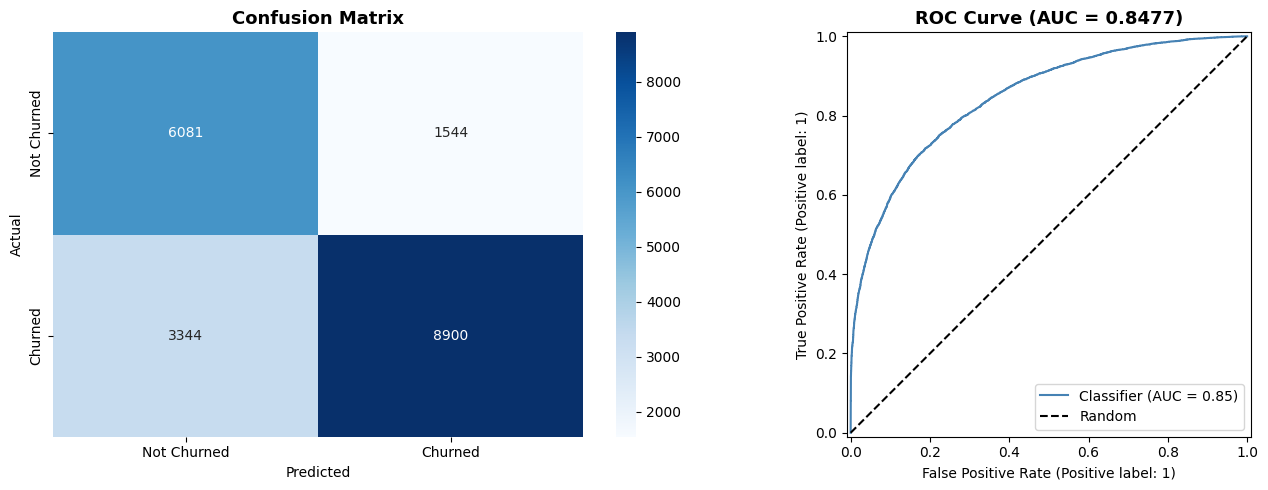

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[0].set_title(f'Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color='steelblue')
axes[1].plot([0,1], [0,1], 'k--', label='Random')
axes[1].set_title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/model_evaluation.png', dpi=150)
plt.show()

In [40]:
# SHAP explainer - TreeExplainer is fast and exact for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (19869, 11)


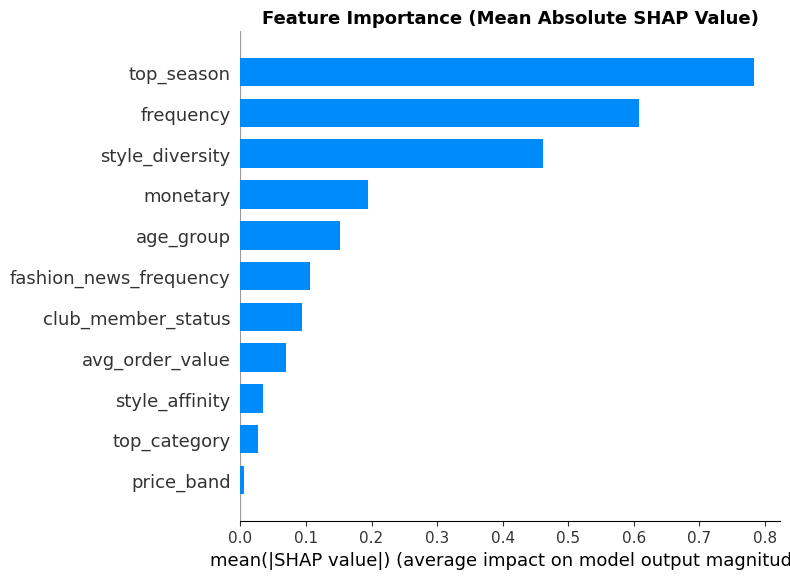

In [41]:
# Plot 1 - Global feature importance (mean absolute SHAP value)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Feature Importance (Mean Absolute SHAP Value)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

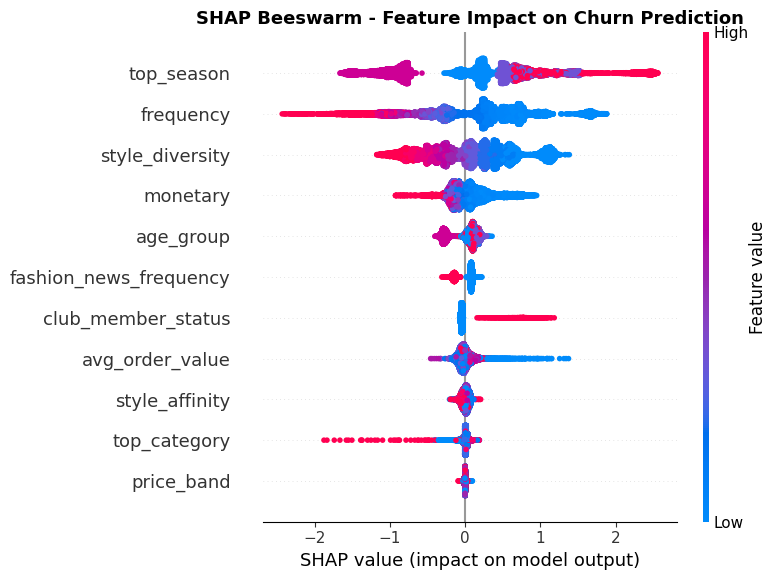

In [42]:
# Plot 2 - SHAP beeswarm plot - shows direction of impact not just magnitude
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm - Feature Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

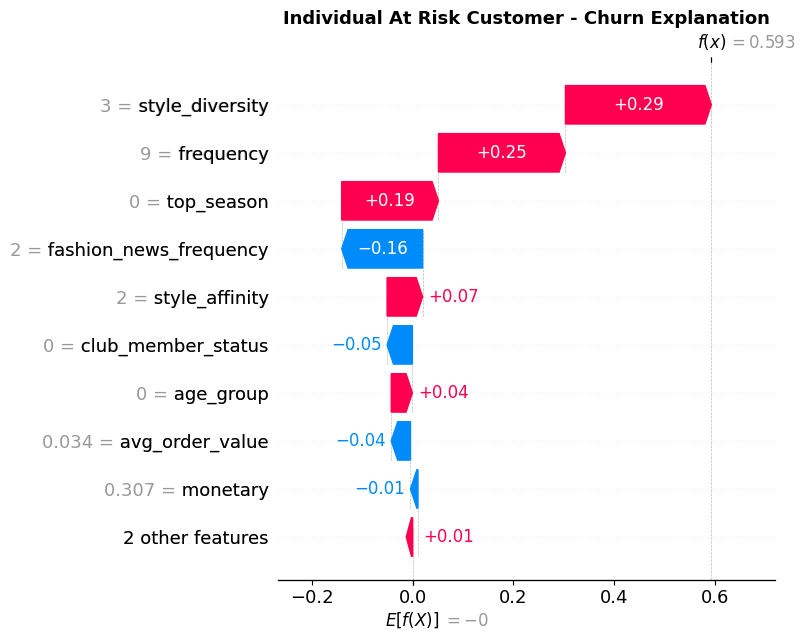

In [43]:
# Plot 3 - Single customer explanation - pick one At Risk customer and explain why
at_risk_indices = customer_segments[customer_segments['segment'] == 'At Risk'].index
at_risk_test_indices = [i for i in at_risk_indices if i in X_test.index]

if len(at_risk_test_indices) > 0:
    sample_idx = at_risk_test_indices[0]
    sample_position = X_test.index.get_loc(sample_idx)
    
    plt.figure(figsize=(12, 4))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sample_position],
            base_values=explainer.expected_value,
            data=X_test.iloc[sample_position],
            feature_names=X_test.columns.tolist()
        ),
        show=False
    )
    plt.title('Individual At Risk Customer - Churn Explanation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/shap_individual.png', dpi=150, bbox_inches='tight')
    plt.show()

In [44]:
# Score all customers not just the test set
all_proba = xgb_model.predict_proba(X)[:, 1]
customer_segments_scored = customer_segments.loc[X.index].copy()
customer_segments_scored['churn_probability'] = all_proba

# High risk = churn probability above 0.7
customer_segments_scored['churn_risk_tier'] = pd.cut(
    customer_segments_scored['churn_probability'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print("Churn risk tier distribution:")
print(customer_segments_scored['churn_risk_tier'].value_counts())

# Cross tab - segment vs churn risk tier
print("\nSegment vs Churn Risk Tier:")
print(pd.crosstab(
    customer_segments_scored['segment'], 
    customer_segments_scored['churn_risk_tier'],
    margins=True
))

Churn risk tier distribution:
churn_risk_tier
High Risk      37874
Low Risk       37756
Medium Risk    23715
Name: count, dtype: int64

Segment vs Churn Risk Tier:
churn_risk_tier      Low Risk  Medium Risk  High Risk    All
segment                                                     
At Risk                 21884        16362      17615  55861
Champions                1538            0          0   1538
Lost                     2668         7256      20257  30181
Potential Loyalists     11666           97          2  11765
All                     37756        23715      37874  99345


In [45]:
customer_segments_scored.to_parquet('/kaggle/working/customer_segments_scored.parquet', index=False)

# Save feature importance as a clean dataframe
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

shap_importance.to_csv('/kaggle/working/shap_importance.csv', index=False)

print("Saved customer_segments_scored.parquet")
print(f"Shape: {customer_segments_scored.shape}")
print(f"\nTop 5 features by SHAP importance:")
print(shap_importance.head())
print(f"\nModel ROC-AUC: {roc_auc:.4f}")
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Saved customer_segments_scored.parquet
Shape: (99345, 27)

Top 5 features by SHAP importance:
           feature  mean_abs_shap
9       top_season       0.784159
0        frequency       0.608758
3  style_diversity       0.461297
1         monetary       0.194229
4        age_group       0.151260

Model ROC-AUC: 0.8477
5-Fold CV AUC: 0.8474 ± 0.0026
